In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(host = "localhost",
                             username = "root",
                             password = "root1234@#",
                             database = "ecommerce")



# list all unique cities where customers are located 

In [7]:
cur = db.cursor()

query = """select distinct customer_city from customers"""

cur.execute(query)

data = cur.fetchall()

data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

# count no.of orders placed in 2017

In [10]:
query = """select Count(order_id) from orders where year(order_purchase_timestamp)=2017"""

cur.execute(query)

data = cur.fetchall()

data

[(180404,)]

# find total sales per category

In [21]:
query = """
SELECT products.product_category,
ROUND(SUM(payments.payment_value),2)
FROM products
JOIN order_items
ON products.product_id = order_items.product_id
JOIN payments
ON payments.order_id = order_items.order_id
GROUP BY products.product_category
"""
cur.execute(query)

data = cur.fetchall()

data

df = pd.DataFrame(data,columns = ["category","sales"])
df

,category,sales
0,perfumery,506738.66
1,Furniture Decoration,1430176.39
2,telephony,486882.05
3,bed table bath,1712553.67
4,automotive,852294.33
...,...,...
69,cds music dvds,1199.43
70,La Cuisine,2913.53
71,Fashion Children's Clothing,785.67
72,PC Gamer,2174.43


# cal % of orders were paid in installments

In [27]:
query = """select  sum(case when payment_installments >= 1 then 1
else 0 end)/count(*)*100 from payments
"""

cur.execute(query)

data = cur.fetchall()

data

[(Decimal('99.9981'),)]

# count of customers from each state

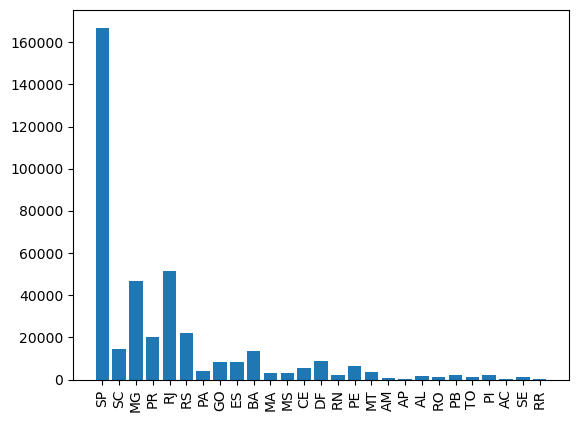

In [35]:
query = """select  customer_state,
count(customer_id) from customers 
group by customer_state
"""

cur.execute(query)

data = cur.fetchall()

data

df = pd.DataFrame(data,columns = ["states","count_customers"])
df

plt.bar(df["states"],df["count_customers"])
plt.xticks(rotation = 90)
plt.show()



# cal no of order per month in 2018

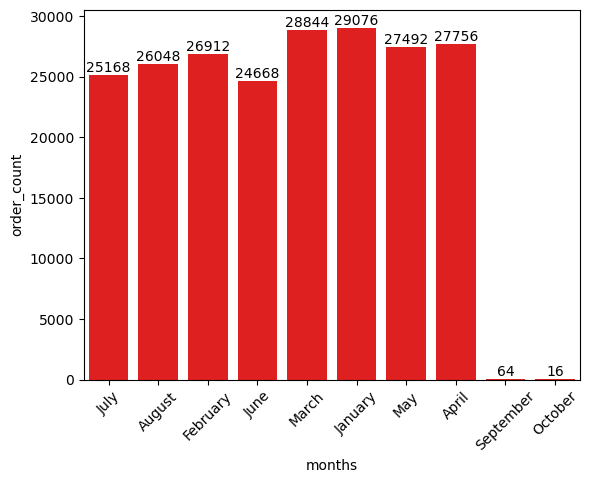

In [44]:
query = """select  monthname(order_purchase_timestamp) months ,
count(order_id) order_count from orders
where year(order_purchase_timestamp) = 2018
group by months
"""

cur.execute(query)

data = cur.fetchall()

data

df = pd.DataFrame(data,columns = ["months","order_count"])
df

ax = sns.barplot(data=df, x="months", y="order_count", color="red")

ax.bar_label(ax.containers[0])

plt.xticks(rotation = 45)

plt.show()

In [48]:
query = """ with count_per_order as (select orders.order_id,orders.customer_id,
count(order_items.order_id) as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id,orders.customer_id)


select customers.customer_city,
round(avg(count_per_order.oc),2) avg_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id 
group by customers.customer_city
;
"""

cur.execute(query)

data = cur.fetchall()

data



[('treze tilias', Decimal('5.09')),
 ('indaial', Decimal('4.46')),
 ('sao jose dos campos', Decimal('4.55')),
 ('sao paulo', Decimal('4.62')),
 ('porto alegre', Decimal('4.70')),
 ('santos', Decimal('4.65')),
 ('sao francisco do sul', Decimal('4.94')),
 ('sao vicente', Decimal('4.36')),
 ('joinville', Decimal('4.41')),
 ('sao vendelino', Decimal('4.00')),
 ('belo horizonte', Decimal('4.57')),
 ('bage', Decimal('4.19')),
 ('gravatai', Decimal('4.25')),
 ('sumare', Decimal('4.53')),
 ('rio de janeiro', Decimal('4.59')),
 ('navegantes', Decimal('4.65')),
 ('chapada do norte', Decimal('4.00')),
 ('frederico westphalen', Decimal('4.29')),
 ('contagem', Decimal('4.58')),
 ('curitiba', Decimal('4.64')),
 ('guaranta', Decimal('4.00')),
 ('miracema', Decimal('4.21')),
 ('campo grande', Decimal('4.57')),
 ('rodeio', Decimal('4.57')),
 ('barueri', Decimal('4.47')),
 ('urussanga', Decimal('4.00')),
 ('osorio', Decimal('4.69')),
 ('duque de caxias', Decimal('4.59')),
 ('coronel joao sa', Decimal('4

In [52]:
query = query = """
SELECT 
    UPPER(products.product_category) AS product_category,
    ROUND(
        (SUM(payments.payment_value) / 
        (SELECT SUM(payment_value) FROM payments)) * 100,
        2
    ) AS sales_percentage
FROM products
JOIN order_items
    ON products.product_id = order_items.product_id
JOIN payments
    ON payments.order_id = order_items.order_id
GROUP BY products.product_category
ORDER BY sales_percentage DESC;
"""

cur.execute(query)

data = cur.fetchall()

data

[('BED TABLE BATH', 10.7),
 ('HEALTH BEAUTY', 10.35),
 ('COMPUTER ACCESSORIES', 9.9),
 ('FURNITURE DECORATION', 8.93),
 ('WATCHES PRESENT', 8.93),
 ('SPORT LEISURE', 8.7),
 ('HOUSEWARES', 6.84),
 ('AUTOMOTIVE', 5.32),
 ('GARDEN TOOLS', 5.24),
 ('COOL STUFF', 4.87),
 ('FURNITURE OFFICE', 4.04),
 ('TOYS', 3.87),
 ('BABIES', 3.37),
 ('PERFUMERY', 3.17),
 ('TELEPHONY', 3.04),
 ('STATIONARY STORE', 1.98),
 ('PET SHOP', 1.94),
 ('PCS', 1.74),
 ('ELECTRONICS', 1.62),
 (None, 1.58),
 ('CONSTRUCTION TOOLS CONSTRUCTION', 1.51),
 ('MUSICAL INSTRUMENTS', 1.46),
 ('ELECTROSTILE', 1.41),
 ('FASHION BAGS AND ACCESSORIES', 1.36),
 ('FIXED TELEPHONY', 1.29),
 ('GAMES CONSOLES', 1.22),
 ('BAGS ACCESSORIES', 1.17),
 ('CASA CONSTRUCAO', 0.85),
 ('ROOM FURNITURE', 0.85),
 ('ELECTRICES 2', 0.78),
 ('AGRO INDUSTRIA E COMERCIO', 0.74),
 ('HOME APPLIANCES', 0.6),
 ('CLIMATIZATION', 0.57),
 ('HOUSE COMFORT', 0.53),
 ('FURNITURE KITCHEN SERVICE AREA DINNER AND GARDEN', 0.47),
 ('CONSTRUCTION TOOLS ILLUMINATION',

In [55]:
query = """
select products.product_category,
count(order_items.product_id),
round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id
group by  products.product_category
"""

cur.execute(query)

data = cur.fetchall()

data

[('HEALTH BEAUTY', 9670, 130.16),
 ('sport leisure', 8641, 114.34),
 ('Cool Stuff', 3796, 167.36),
 ('computer accessories', 7827, 116.51),
 ('Watches present', 5991, 201.14),
 ('housewares', 6964, 90.79),
 ('electronics', 2767, 57.91),
 (None, 1603, 112.0),
 ('toys', 4117, 117.55),
 ('bed table bath', 11115, 93.3),
 ('Games consoles', 1137, 138.49),
 ('automotive', 4235, 139.96),
 ('Furniture Decoration', 8334, 87.56),
 ('home appliances', 771, 103.98),
 ('telephony', 4545, 71.21),
 ('Construction Tools Construction', 929, 155.73),
 ('perfumery', 3419, 116.74),
 ('stationary store', 2517, 91.75),
 ('Room Furniture', 503, 137.01),
 ('Fashion Bags and Accessories', 2031, 75.25),
 ('Garden tools', 4347, 111.63),
 ('Fashion Underwear and Beach Fashion', 131, 72.84),
 ('pet Shop', 1947, 110.07),
 ('SIGNALIZATION AND SAFETY', 199, 108.09),
 ('ELECTRICES 2', 238, 476.12),
 ("Fashion Women's Clothing", 48, 58.41),
 ('Bags Accessories', 1092, 128.6),
 ('General Interest Books', 553, 84.73),
 (

In [58]:
query = """
SELECT *,
       DENSE_RANK() OVER(ORDER BY revenue DESC) AS rn
FROM
(
    SELECT 
        order_items.seller_id,
        SUM(payments.payment_value) AS revenue
    FROM order_items
    JOIN payments
        ON order_items.order_id = payments.order_id
    GROUP BY order_items.seller_id
) AS a;
"""

cur.execute(query)

data = cur.fetchall()

data

[('7c67e1448b00f6e969d365cea6b010ab', 507166.9073021412, 1),
 ('1025f0e2d44d7041d6cf58b6550e0bfa', 308222.0398402214, 2),
 ('4a3ca9315b744ce9f8e9374361493884', 301245.26976528764, 3),
 ('1f50f920176fa81dab994f9023523100', 290253.42012761533, 4),
 ('53243585a1d6dc2643021fd1853d8905', 284903.0804977417, 5),
 ('da8622b14eb17ae2831f4ac5b9dab84a', 272219.31931465864, 6),
 ('4869f7a5dfa277a7dca6462dcf3b52b2', 264166.1209387779, 7),
 ('955fee9216a65b617aa5c0531780ce60', 236322.30050226487, 8),
 ('fa1c13f2614d7b5c4749cbc52fecda94', 206513.22986984253, 9),
 ('7e93a43ef30c4f03f38b393420bc753a', 185134.20970630646, 10),
 ('6560211a19b47992c3666cc44a7e94c0', 179657.74904833734, 11),
 ('7a67c85e85bb2ce8582c35f2203ad736', 169030.80002561212, 12),
 ('25c5c91f63607446a97b143d2d535d31', 160534.7397725582, 13),
 ('a1043bafd471dff536d0c462352beb48', 154356.91018915176, 14),
 ('46dc3b2cc0980fb8ec44634e21d2718e', 148864.3400707245, 15),
 ('b37c4c02bda3161a7546a4e6d222d5b2', 145319.04013061523, 16),
 ('620c